<a href="https://colab.research.google.com/github/RhyanMorais/neural-network-cancer-severity/blob/main/_cancer_severity_prediction_using_neural_networks_2015_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# BIBLIOTECAS
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as pl
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from pathlib import Path

In [7]:
DATA_FILE = "global_cancer_patients_2015_2024.csv"

data_path = Path("data") / DATA_FILE

if not data_path.exists():
    raise FileNotFoundError(
        "Arquivo não encontrado. Coloque o CSV na pasta data/ "
        "na raiz do projeto."
    )

df = pd.read_csv(data_path)
df.head()


,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


/tmp/ipython-input-3884742892.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Gender', y='Target_Severity_Score',
/tmp/ipython-input-3884742892.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Gender', y='Target_Severity_Score',


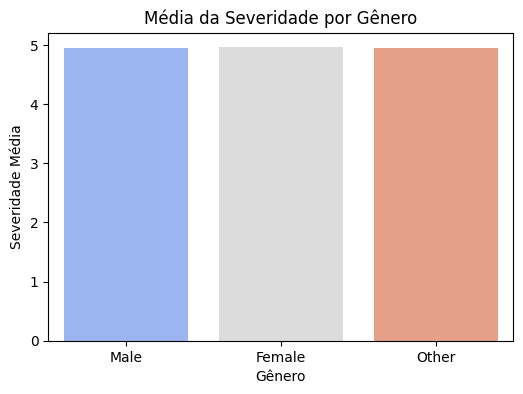

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Gender', y='Target_Severity_Score',
            palette='coolwarm', estimator='mean', ci=None)
plt.title('Média da Severidade por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Severidade Média')
plt.show()


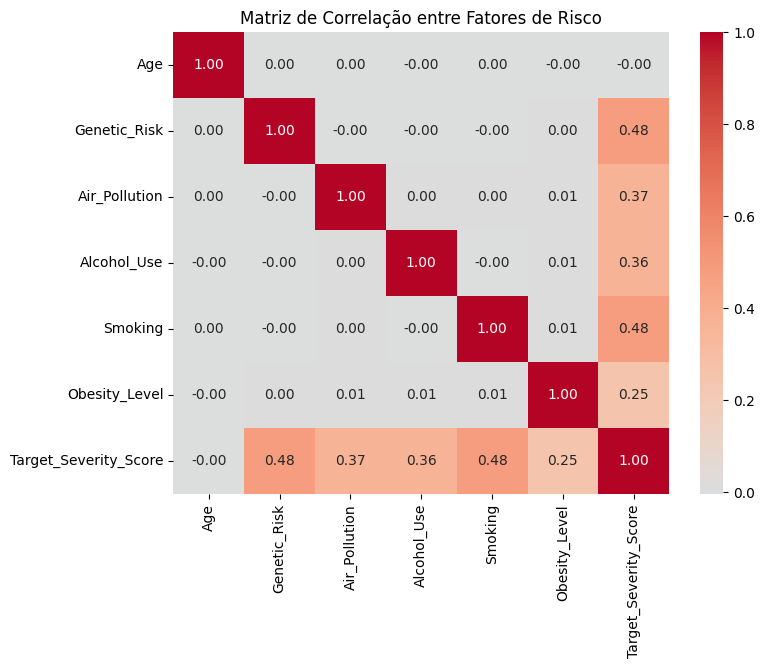

In [9]:
# Variáveis numéricas utilizadas no modelo
num_cols = ['Age', 'Genetic_Risk', 'Air_Pollution',
            'Alcohol_Use', 'Smoking', 'Obesity_Level', 'Target_Severity_Score']

# Matriz de correlação com duas casas decimais
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de Correlação entre Fatores de Risco')
plt.show()


Formato da base: (50000, 15)

Colunas: ['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level', 'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years', 'Target_Severity_Score']

Treino: (40000, 9)  | Teste: (10000, 9)
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 3.1036 - mae: 1.0885 - val_loss: 0.3097 - val_mae: 0.4819
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3062 - mae: 0.4771 - val_loss: 0.3082 - val_mae: 0.4814
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3026 - mae: 0.4742 - val_loss: 0.3187 - val_mae: 0.4869
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3039 - mae: 0.4738 - val_loss: 0.3138 - val_mae: 0.4839
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3051 - mae: 0.4753 - val_loss: 0.3111 - val_mae: 0.4828
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3018 - mae: 0.4730 - val_loss: 0.3102 - val_mae: 0.4828
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.3004 - mae: 0.4720 - val_loss: 0.3185 - val_mae: 0.4863
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3037 - mae: 0.4742 - val_loss: 0.3133 - val_mae: 0.4838
Epoch 9/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/st

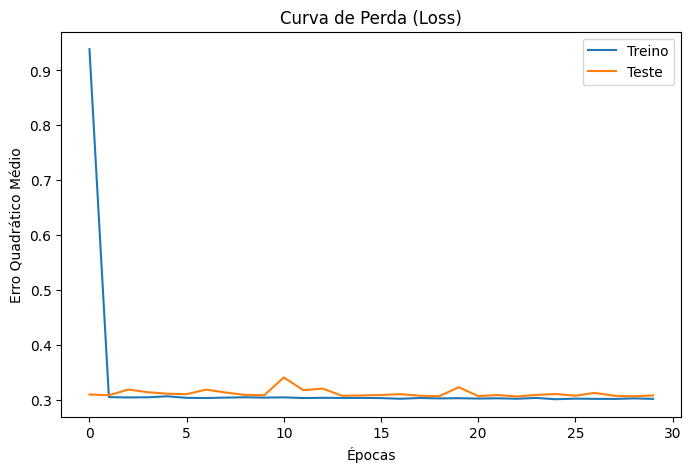

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


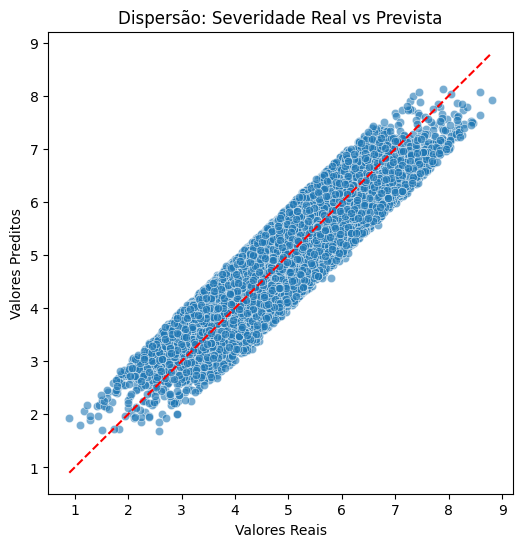

In [10]:
# Verificar informações básicas
print("Formato da base:", df.shape)
print("\nColunas:", df.columns.tolist())
df.head()

# 1 SELEÇÃO DAS VARIÁVEIS
# Variáveis numéricas e categóricas

# num_cols = ['Age','Genetic_Risk','Air_Pollution','Alcohol_Use','Smoking',
#              'Obesity_Level','Treatment_Cost_USD','Survival_Years']
# cat_cols = ['Gender','Country_Region','Cancer_Type','Cancer_Stage']


num_cols = ['Age','Genetic_Risk','Air_Pollution','Alcohol_Use','Smoking','Obesity_Level']
cat_cols = ['Gender']

# Variável alvo
target = 'Target_Severity_Score'

# 2 PRÉ-PROCESSAMENTO
# Codificar variáveis categóricas (One-Hot)
df_encoded = pd.get_dummies(df[cat_cols])

# Normalizar variáveis numéricas
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]), columns=num_cols)

# Unir dados tratados
X = pd.concat([df_scaled, df_encoded], axis=1)
y = df[target]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTreino:", X_train.shape, " | Teste:", X_test.shape)

# 3 CONSTRUÇÃO DO MODELO
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=['mae'])


# 4 TREINAMENTO
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=30,
                    batch_size=32,
                    verbose=1)

# 6 AVALIAÇÃO
results = model.evaluate(X_test, y_test, verbose=0)
print(f"\n Erro Médio Absoluto (MAE): {results[1]:.3f}")
print(f"Erro Quadrático Médio (MSE): {results[0]:.3f}")

# 7 VISUALIZAÇÃO DO TREINAMENTO
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Teste')
plt.title('Curva de Perda (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Erro Quadrático Médio')
plt.legend()
plt.show()

# 8 GRÁFICO DE VALORES REAIS vs PREDITOS
y_pred = model.predict(X_test).flatten()

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Preditos')
plt.title('Dispersão: Severidade Real vs Prevista')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
🔍 AVALIAÇÃO DO MODELO
MAE (Erro Médio Absoluto): 0.4810
MSE (Erro Quadrático Médio): 0.3079
RMSE (Raiz do Erro Quadrático): 0.5549
R² (Coeficiente de Determinação): 0.7833


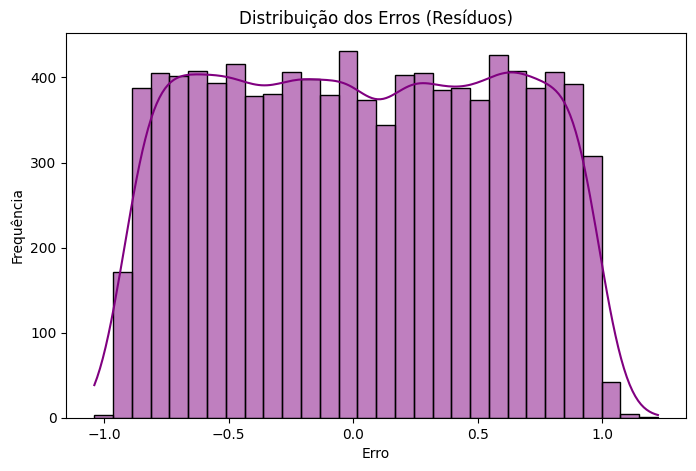

In [11]:
# Fazendo predições
y_pred = model.predict(X_test).flatten()
# Cálculo das métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("🔍 AVALIAÇÃO DO MODELO")
print(f"MAE (Erro Médio Absoluto): {mae:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse:.4f}")
print(f"RMSE (Raiz do Erro Quadrático): {rmse:.4f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")


# Distribuição dos erros (resíduos)
residuos = y_test - y_pred
plt.figure(figsize=(8,5))
sns.histplot(residuos, bins=30, kde=True, color='purple')
plt.title('Distribuição dos Erros (Resíduos)')
plt.xlabel('Erro')
plt.ylabel('Frequência')
plt.show()


🔍 10 Variáveis mais influentes na predição da severidade:

        Variável  Importância
1   Genetic_Risk     0.228992
4        Smoking     0.206762
3    Alcohol_Use     0.187043
2  Air_Pollution     0.183853
5  Obesity_Level     0.173028
0            Age     0.171498
6  Gender_Female     0.131315
7    Gender_Male     0.103231
8   Gender_Other     0.100583


/tmp/ipython-input-236005268.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10), x='Importância', y='Variável', palette='viridis')


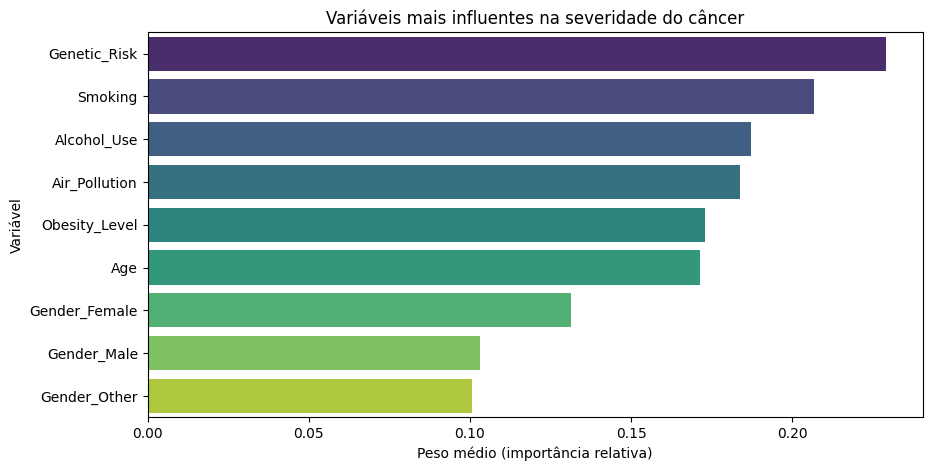

In [12]:
#  Pegando os pesos da primeira camada da rede
pesos, bias = model.layers[0].get_weights()

# Cálculo da importância média absoluta de cada variável de entrada
importancia = np.mean(np.abs(pesos), axis=1)

# Criar DataFrame com as variáveis e seus pesos médios
feature_importance = pd.DataFrame({
    'Variável': X.columns,
    'Importância': importancia
}).sort_values(by='Importância', ascending=False)

# Exibir as 10 variáveis mais influentes
print("🔍 10 Variáveis mais influentes na predição da severidade:\n")
print(feature_importance.head(10))

# Gráfico de barras
plt.figure(figsize=(10,5))
sns.barplot(data=feature_importance.head(10), x='Importância', y='Variável', palette='viridis')
plt.title('Variáveis mais influentes na severidade do câncer')
plt.xlabel('Peso médio (importância relativa)')
plt.ylabel('Variável')
plt.show()


## Conclusão

Este projeto teve como objetivo aplicar uma rede neural artificial do tipo Perceptron Multicamadas para a predição da severidade do câncer a partir de fatores clínicos, comportamentais e ambientais. A análise exploratória permitiu compreender o comportamento das variáveis e selecionar atributos relevantes para a modelagem, garantindo coerência com o objetivo do estudo. O modelo apresentou convergência rápida e estável, com métricas semelhantes nos conjuntos de treino e teste, indicando boa capacidade de generalização e ausência de overfitting. A análise dos resultados demonstrou que fatores como risco genético, tabagismo, obesidade, poluição do ar e consumo de álcool exercem influência significativa sobre a severidade da doença. De forma geral, os resultados indicam que redes neurais constituem uma abordagem eficaz para modelar relações não lineares e apoiar análises preditivas em contextos de saúde, podendo contribuir para estudos de risco e estratégias de prevenção.
